# Support Vector Classifier Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.datasets import make_classification

In [2]:
## crating the synthetic data points
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_clusters_per_class=1,n_redundant=0)


In [3]:
pd.DataFrame(X).head()

,0,1
0,-1.109463,1.768061
1,-0.853484,-0.830759
2,0.769077,-1.269778
3,0.359453,-1.797662
4,-1.473704,-0.190234


<Axes: xlabel='0', ylabel='1'>

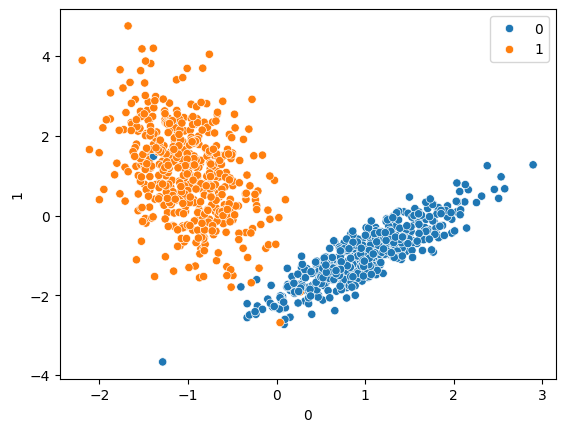

In [4]:
sns.scatterplot(x = pd.DataFrame(X)[0], y = pd.DataFrame(X)[1], hue=y)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=23)

In [6]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [7]:
y_pred = svc.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.992
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       133
           1       0.99      0.99      0.99       117

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

[[132   1]
 [  1 116]]


Due to clearly separable points we get the good accuracy 

if we increase the clusters_pre_class is more then what happens lets see

In [9]:
## Creating the data
X_new, y_new = make_classification(n_samples=1000, n_features=2, n_classes=2, n_clusters_per_class=2, n_redundant=0, random_state=42)

<Axes: xlabel='0', ylabel='1'>

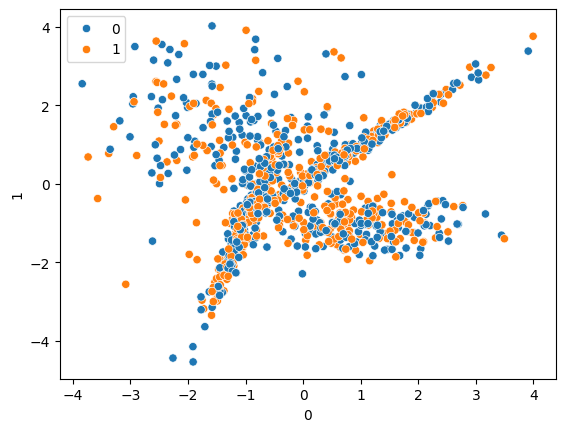

In [10]:
sns.scatterplot(x = pd.DataFrame(X_new)[0], y = pd.DataFrame(X_new)[1], hue=y)

In [11]:
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

In [12]:
svc_new = SVC(kernel='linear')
svc_new.fit(X_new_train, y_new_train)
y_new_pred = svc_new.predict(X_new_test)


In [13]:
print(accuracy_score(y_new_test, y_new_pred))
print(classification_report(y_new_test, y_new_pred))
print(confusion_matrix(y_new_test, y_new_pred))

0.8766666666666667
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       148
           1       0.90      0.86      0.88       152

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

[[133  15]
 [ 22 130]]


Here you can see that the accuracy has dropped

## Applying rbf Kernel

In [14]:
rbf = SVC(kernel='rbf')
rbf.fit(X_new_train, y_new_train)


SVC()

In [15]:
y_pred=rbf.predict(X_new_test)

In [16]:
print(accuracy_score(y_new_test, y_pred))
print(classification_report(y_new_test, y_pred))

0.8866666666666667
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       148
           1       0.93      0.84      0.88       152

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



# Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

params = {'C': [0.1, 1, 10, 100, 1000], 
          'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
          'kernel': ['rbf']}

In [18]:
grid = GridSearchCV(SVC(), param_grid=params, refit=True, cv=5, verbose=3 )

In [19]:
grid.fit(X_new_train, y_new_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.921 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.864 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.886 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.850 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.864 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.886 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.850 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.879 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.864 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.821 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.886 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [20]:
grid.best_params_

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}

In [21]:
grid.best_score_

0.8985714285714286

In [22]:
y_pred = grid.predict(X_new_test)
print(accuracy_score(y_new_test, y_pred))
print(classification_report(y_pred, y_new_test))

0.9166666666666666
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       167
           1       0.86      0.98      0.91       133

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



So here using the Hyperparameter tuning we have increased the accuracy